# CardioScope-XAI — XGBoost Classifier
Trains the tabular risk classifier on UCI Cleveland features, evaluates performance, and logs everything to MLflow.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.data_loader import load_and_clean
from src.feature_engineering import build_feature_matrix
from src.xgboost_model import train, evaluate, cross_validate_model, DEFAULT_PARAMS

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

## 1. Load & Prepare Data

In [2]:
df = load_and_clean('../data/raw/heart_disease_uci.csv')
X, scaler = build_feature_matrix(df, fit_scaler=True)
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {X.shape[1]}')

[data_loader] Using 'Cleveland' subset: 304 rows.
[data_loader] Dropped 7 rows with missing values.
[data_loader] Clean dataset: 297 rows, 14 columns.
[data_loader] Class balance — 0 (no disease): 160, 1 (disease): 137
[feature_engineering] Scaler fitted and saved to models\scaler.pkl
[feature_engineering] Final feature matrix: 25 features, 297 samples.
Train: (237, 25) | Test: (60, 25)
Features: 25


## 2. Train XGBoost + Log to MLflow

In [3]:
model, metrics = train(X_train, y_train, X_test, y_test, log_mlflow=True)

print('\n── Test Set Metrics ──')
for k, v in metrics.items():
    print(f'  {k:12s}: {v}')

2026/05/22 21:46:51 INFO mlflow.tracking.fluent: Experiment with name 'CardioScope-XAI / XGBoost' does not exist. Creating a new experiment.
C:\Users\admin\Desktop\CardioScope-XAI\CardioScope-XAI\venv\Lib\site-packages\xgboost\core.py:160: UserWarning: [21:46:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
  warnings.warn(smsg, UserWarning)


[xgboost_model] Model saved → models\xgboost_model.pkl

── Test Set Metrics ──
  accuracy    : 0.85
  recall      : 0.7857
  precision   : 0.88
  f1          : 0.8302
  auc_roc     : 0.9342


## 3. Full Evaluation Report

In [4]:
full_metrics = evaluate(model, X_test, y_test)


              precision    recall  f1-score   support

  No Disease       0.83      0.91      0.87        32
     Disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



## 4. Confusion Matrix

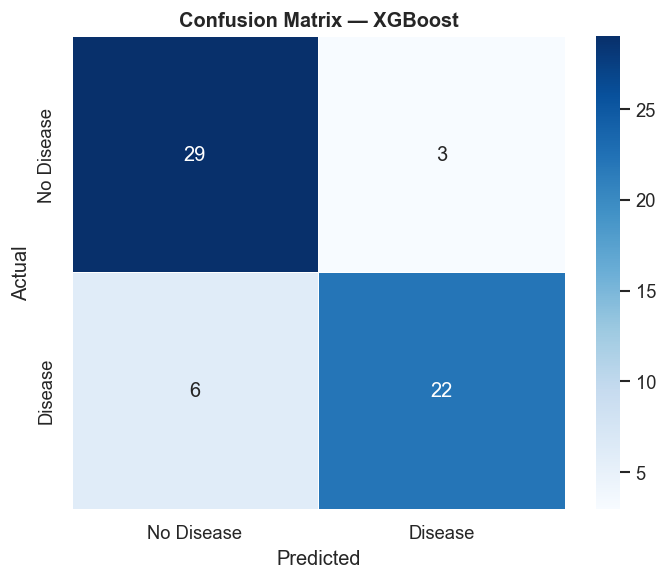

True Negatives : 29  |  False Positives: 3
False Negatives: 6  |  True Positives : 22

False Negative Rate (missed disease): 21.43%


In [5]:
cm = np.array(full_metrics['confusion_matrix'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease'],
    linewidths=0.5
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives : {tn}  |  False Positives: {fp}')
print(f'False Negatives: {fn}  |  True Positives : {tp}')
print(f'\nFalse Negative Rate (missed disease): {fn/(fn+tp):.2%}')

## 5. Cross-Validation (5-Fold Stratified)

In [6]:
cv_results = cross_validate_model(X, y, n_splits=5)

print('── 5-Fold Cross-Validation ──')
for metric, vals in cv_results.items():
    print(f'  {metric:12s}: {vals["mean"]:.4f} ± {vals["std"]:.4f}')

── 5-Fold Cross-Validation ──
  accuracy    : 0.8247 ± 0.0478
  recall      : 0.8093 ± 0.0791
  precision   : 0.8136 ± 0.0629
  f1          : 0.8090 ± 0.0526
  roc_auc     : 0.8875 ± 0.0498


## 6. Feature Importance

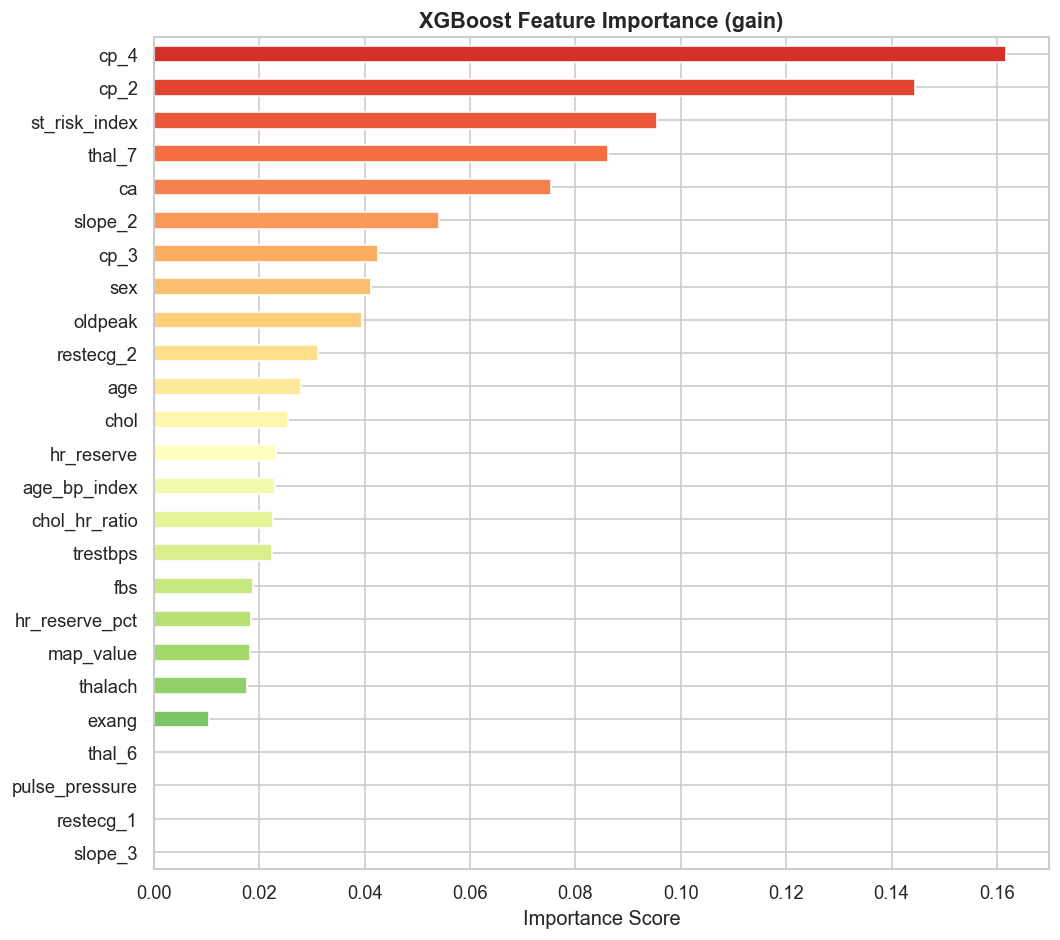


Top 10 most important features:
cp_4             0.161752
cp_2             0.144360
st_risk_index    0.095547
thal_7           0.086203
ca               0.075432
slope_2          0.054048
cp_3             0.042595
sex              0.041307
oldpeak          0.039473
restecg_2        0.031167


In [7]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(importance)))
importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('XGBoost Feature Importance (gain)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 most important features:')
print(importance.tail(10).sort_values(ascending=False).to_string())

## 7. ROC Curve

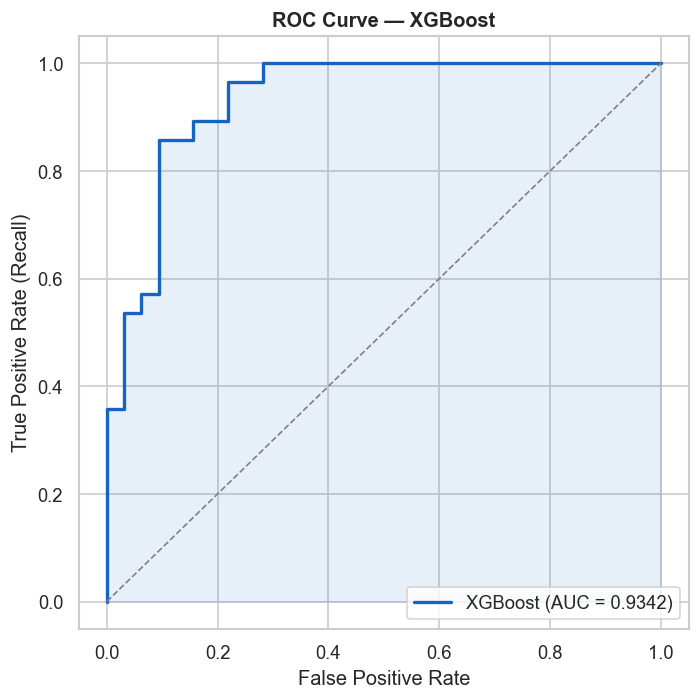

In [8]:
from sklearn.metrics import roc_curve

y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='#1565C0', lw=2, label=f'XGBoost (AUC = {full_metrics["auc_roc"]:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
ax.fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — XGBoost', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Model Summary

| Metric | Value |
|---|---|
| Accuracy | See output above |
| Recall (sensitivity) | Priority metric — minimise false negatives |
| AUC-ROC | Threshold-independent performance |
| Model saved | `models/xgboost_model.pkl` |
| MLflow logged | `mlflow/` directory |